In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

In [2]:
times=data['time'].values/(1e9 * 60); times=times.astype(float);
minutes=1/times[1] #1 / minutes per timestep = timesteps per minute
job_array=False;index_adjust=0
ocean_fraction=2/8

In [3]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(PlottingFunctions, inspect.isfunction)]
# functions

In [4]:
#CL VS NONCL
################################################################

In [5]:
##########################################################
#PLOTTING

In [6]:
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

In [7]:
def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
all_cloudbase=min_all_cloudbase
print(f"Minimum Cloudbase is: {min_all_cloudbase}\n")

Minimum Cloudbase is: 1.2463867664337158



In [8]:
#NEEDED TO PLOT THE CORRECT DATA #*#*
data_type1="Tracked_Entrainment_VMF"
data_type2="Tracked_Combined_Entrainment"

In [9]:
PROCESSING=False
# PROCESSING=True

In [10]:
type3='general'
type3='cloudy'

type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type1}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5" 
if PROCESSING==False:
    filePath=dir3 + f"{data_type1}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        # print(key)

#this is needed because I wanted to keep consistent with the titles in "profile"
suffix = '_C' if type3 == 'cloudy' else '_G'
for prefix in [type1, type2]:
    for group in ['ALL', 'SHALLOW', 'DEEP']:
        var_name = f"{prefix}_{group}_profile_array_NET{suffix}"
        var_name_target = f"{prefix}_{group}_net"
        globals()[var_name_target] = globals()[var_name]
        print(f"{var_name_target} = {var_name}")

CL_ALL_net = CL_ALL_profile_array_NET_C
CL_SHALLOW_net = CL_SHALLOW_profile_array_NET_C
CL_DEEP_net = CL_DEEP_profile_array_NET_C
nonCL_ALL_net = nonCL_ALL_profile_array_NET_C
nonCL_SHALLOW_net = nonCL_SHALLOW_profile_array_NET_C
nonCL_DEEP_net = nonCL_DEEP_profile_array_NET_C


In [11]:
data_type2="Tracked_Combined_Entrainment"
type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3 + f"{data_type2}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
if PROCESSING==False:
    filePath=dir3 + f"{data_type2}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        print(key)

CL_ALL_profile_array_C_TO_G
CL_ALL_profile_array_G_TO_C
CL_DEEP_profile_array_C_TO_G
CL_DEEP_profile_array_G_TO_C
CL_SHALLOW_profile_array_C_TO_G
CL_SHALLOW_profile_array_G_TO_C
nonCL_ALL_profile_array_C_TO_G
nonCL_ALL_profile_array_G_TO_C
nonCL_DEEP_profile_array_C_TO_G
nonCL_DEEP_profile_array_G_TO_C
nonCL_SHALLOW_profile_array_C_TO_G
nonCL_SHALLOW_profile_array_G_TO_C


In [12]:
#REDUCING FOR CONFERENCE FIGURE

def PlotOne(ax):
    import matplotlib.pyplot as plt
    lw=1
    
    # List of profile arrays and their corresponding labels and x-axis titles
    profiles = [
        (CL_ALL_net, CL_SHALLOW_net, CL_DEEP_net, 'net', 'CL'),
        (nonCL_ALL_net, nonCL_SHALLOW_net, nonCL_DEEP_net, 'net', 'nonCL')
    ]
    
    cutoff_height=100
    # cutoff_height=7.5
    # cutoff_height=2
    z_cutoff=np.where(CL_ALL_net[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z
    
    # Loop through profiles for CL and nonCL
    for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
        # Compute the averaged profile for ALL
        ALL_profile = averaged_profiles(ALL_profile_array)
        SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
        DEEP_profile = averaged_profiles(DEEP_profile_array)
    
        #CUT BELOW CERTAIN Z
        ALL_profile=ALL_profile[:z_cutoff]
        SHALLOW_profile=SHALLOW_profile[:z_cutoff]
        DEEP_profile=DEEP_profile[:z_cutoff]
    
        # Plot the profile for ALL (CL and nonCL) on top of each other
        if CLlabel == 'CL':
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='ALL (CL)',lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], color='green', label='SHALLOW (CL)',lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], color='blue', label='DEEP (CL)',lw=lw)
        else:
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='ALL (nonCL)',lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label='SHALLOW (nonCL)',lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label='DEEP (nonCL)',lw=lw)
    
        apply_scientific_notation([ax])
    
    
    # ax.set_ylim(0,3)
    
    # Add labels and title
    ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
    ax.set_ylabel('z (km)')
    ax.grid(True)
    
    ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)
    
    # Show legend
    ax.legend()
    
    #MEAN CLOUD BASE
    ax.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
    # Set up the main title and adjust layout
    ax.set_title(f'CL vs nonCL (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n {type3.title()} Updraft Net Entrainment from Tracked Lagrangian Parcels')
    plt.tight_layout()
    
    return ax


# #PLOTTING
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111)
# ax1=PlotOne(ax)

In [13]:
#REDUCING FOR CONFERENCE FIGURE
def PlotTwo(ax):
    lw=1
    
    # List of profile arrays and their corresponding labels and x-axis titles
    profiles = [
        (CL_ALL_profile_array_G_TO_C, CL_SHALLOW_profile_array_G_TO_C, CL_DEEP_profile_array_G_TO_C, 'G_TO_C', 'CL'),
        (nonCL_ALL_profile_array_G_TO_C, nonCL_SHALLOW_profile_array_G_TO_C, nonCL_DEEP_profile_array_G_TO_C, 'G_TO_C', 'nonCL')
    ]
    
    
    cutoff_height=100
    # z_cutoff=7.5
    z_cutoff=np.where(CL_ALL_profile_array_G_TO_C[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

    
    # Loop through profiles for CL and nonCL
    for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
        # Compute the averaged profile for ALL
        ALL_profile = averaged_profiles(ALL_profile_array)
        SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
        DEEP_profile = averaged_profiles(DEEP_profile_array)
    
        #CUT BELOW CERTAIN Z
        ALL_profile=ALL_profile[:z_cutoff]
        SHALLOW_profile=SHALLOW_profile[:z_cutoff]
        DEEP_profile=DEEP_profile[:z_cutoff]
    
        # Plot the profile for ALL (CL and nonCL) on top of each other
        if CLlabel == 'CL':
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='ALL (CL)',lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], color='green', label='SHALLOW (CL)',lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], color='blue', label='DEEP (CL)',lw=lw)
        else:
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='ALL (nonCL)',lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label='SHALLOW (nonCL)',lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label='DEEP (nonCL)',lw=lw)
    
        apply_scientific_notation([ax]) 
    
    # ax.set_ylim(0,3)
    
    # Add labels and title
    ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
    ax.set_ylabel('z (km)')
    ax.grid(True)
    
    ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)
    
    # Show legend
    ax.legend()
    
    #MEAN CLOUD BASE
    ax.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
    # Set up the main title and adjust layout
    ax.set_title(f'CL vs nonCL (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n Updraft General to Cloudy Entrainment from Tracked Lagrangian Parcels')
    plt.tight_layout()
    
    return ax


# #PLOTTING
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111)
# ax2=PlotTwo(ax)

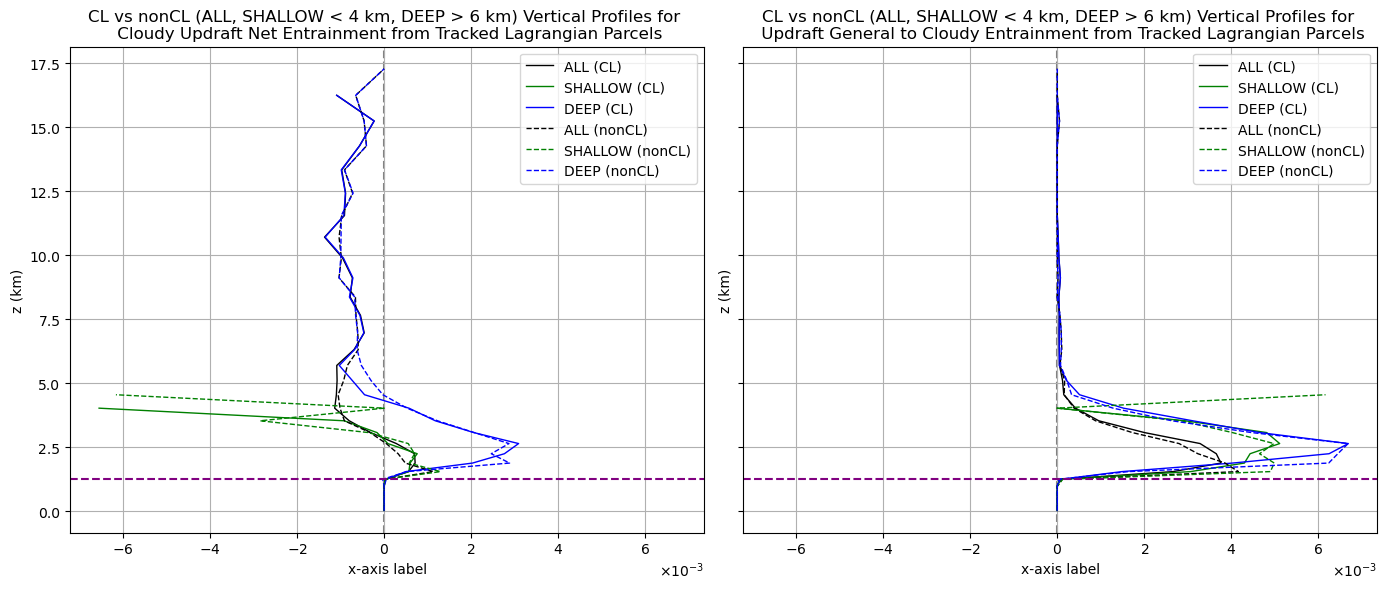

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True);
PlotOne(axs[0])
PlotTwo(axs[1])
MatchAxisLimits([axs[0],axs[1]],dim='x')

In [52]:
##########################################################################################
#SBZ vs nonSBZ Tracked Entrainment Profiles

In [53]:
##########################################################
#PLOTTING

In [71]:
type3='general'
type3='cloudy'

type1='SBZ';type2='nonSBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type1}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5" 
if PROCESSING==False:
    filePath=dir3 + f"{data_type1}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        # print(key)

#this is needed because I wanted to keep consistent with the titles in "profile"
suffix = '_C' if type3 == 'cloudy' else '_G'
for prefix in [type1, type2]:
    for group in ['ALL', 'SHALLOW', 'DEEP']:
        var_name = f"{prefix}_{group}_profile_array_NET{suffix}"
        var_name_target = f"{prefix}_{group}_net"
        globals()[var_name_target] = globals()[var_name]
        print(f"{var_name_target} = {var_name}")

SBZ_ALL_net = SBZ_ALL_profile_array_NET_C
SBZ_SHALLOW_net = SBZ_SHALLOW_profile_array_NET_C
SBZ_DEEP_net = SBZ_DEEP_profile_array_NET_C
nonSBZ_ALL_net = nonSBZ_ALL_profile_array_NET_C
nonSBZ_SHALLOW_net = nonSBZ_SHALLOW_profile_array_NET_C
nonSBZ_DEEP_net = nonSBZ_DEEP_profile_array_NET_C


In [72]:
type1='SBZ';type2='nonSBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type2}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
if PROCESSING==False:
    filePath=dir3 + f"{data_type2}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        print(key)

SBZ_ALL_profile_array_C_TO_G
SBZ_ALL_profile_array_G_TO_C
SBZ_DEEP_profile_array_C_TO_G
SBZ_DEEP_profile_array_G_TO_C
SBZ_SHALLOW_profile_array_C_TO_G
SBZ_SHALLOW_profile_array_G_TO_C
nonSBZ_ALL_profile_array_C_TO_G
nonSBZ_ALL_profile_array_G_TO_C
nonSBZ_DEEP_profile_array_C_TO_G
nonSBZ_DEEP_profile_array_G_TO_C
nonSBZ_SHALLOW_profile_array_C_TO_G
nonSBZ_SHALLOW_profile_array_G_TO_C


In [73]:
#REDUCING FOR CONFERENCE FIGURE
def PlotOne(ax):
    
    import matplotlib.pyplot as plt
    lw=1
    
    # List of profile arrays and their corresponding labels and x-axis titles
    profiles = [
        (SBZ_ALL_net, SBZ_SHALLOW_net, SBZ_DEEP_net, 'net', 'CL'),
        (nonSBZ_ALL_net, nonSBZ_SHALLOW_net, nonSBZ_DEEP_net, 'net', 'nonCL')
    ]
    
    # Loop through profiles for CL and nonCL
    for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
        # Compute the averaged profile for ALL
        ALL_profile = averaged_profiles(ALL_profile_array)
        SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
        DEEP_profile = averaged_profiles(DEEP_profile_array)
        
        # Plot the profile for ALL (CL and nonCL) on top of each other
        if CLlabel == 'CL':
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='ALL (SBZ)',lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], color='green', label='SHALLOW (SBZ)',lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], color='blue', label='DEEP (SBZ)',lw=lw)
        else:
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='ALL (nonSBZ)',lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label='SHALLOW (nonSBZ)',lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label='DEEP (nonSBZ)',lw=lw)
    
    # Add labels and title
    ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
    ax.set_ylabel('z (km)')
    ax.grid(True)
    
    
    # ax.set_ylim(0,3)
    
    # Show legend
    ax.legend()
    
    #MEAN CLOUD BASE
    ax.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
    apply_scientific_notation([ax])
    
    # Set up the main title and adjust layout
    ax.set_title(f'SBZ vs nonSBZ (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n {type3.title()} Updraft Net Entrainment from Tracked Lagrangian Parcels')
    plt.tight_layout()

    return ax

# #PLOTTING
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111)
# ax1=PlotOne(ax)


In [74]:
#REDUCING FOR CONFERENCE FIGURE
def PlotTwo(ax):
    import matplotlib.pyplot as plt
    lw=1
    
    # List of profile arrays and their corresponding labels and x-axis titles
    profiles = [
        (SBZ_ALL_profile_array_G_TO_C, SBZ_SHALLOW_profile_array_G_TO_C, SBZ_DEEP_profile_array_G_TO_C, 'G_TO_C', 'SBZ'),
        (nonSBZ_ALL_profile_array_G_TO_C, nonSBZ_SHALLOW_profile_array_G_TO_C, nonSBZ_DEEP_profile_array_G_TO_C, 'G_TO_C', 'nonSBZ')
    ]
    
    
    cutoff_height=100
    # z_cutoff=7.5
    z_cutoff=np.where(SBZ_ALL_profile_array_G_TO_C[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z
    
    # Loop through profiles for SBZ and nonSBZ
    for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, SBZlabel) in enumerate(profiles):
        # Compute the averaged profile for ALL
        ALL_profile = averaged_profiles(ALL_profile_array)
        SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
        DEEP_profile = averaged_profiles(DEEP_profile_array)
    
        #CUT BELOW CERTAIN Z
        ALL_profile=ALL_profile[:z_cutoff]
        SHALLOW_profile=SHALLOW_profile[:z_cutoff]
        DEEP_profile=DEEP_profile[:z_cutoff]
    
        # Plot the profile for ALL (SBZ and nonSBZ) on top of each other
        if SBZlabel == 'SBZ':
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='ALL (SBZ)',lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], color='green', label='SHALLOW (SBZ)',lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], color='blue', label='DEEP (SBZ)',lw=lw)
        else:
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='ALL (nonSBZ)',lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label='SHALLOW (nonSBZ)',lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label='DEEP (nonSBZ)',lw=lw)
    
        apply_scientific_notation([ax])
    
    
    
    # ax.set_ylim(0,3)
    
    # Add labels and title
    ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
    ax.set_ylabel('z (km)')
    ax.grid(True)
    
    ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)
    
    # Show legend
    ax.legend()
    
    #MEAN CLOUD BASE
    ax.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
    # Set up the main title and adjust layout
    ax.set_title(f'SBZ vs nonSBZ (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n Updraft General to Cloudy Entrainment from Tracked Lagrangian Parcels')
    plt.tight_layout()

    return ax

# #PLOTTING
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111)
# ax2=PlotTwo(ax)

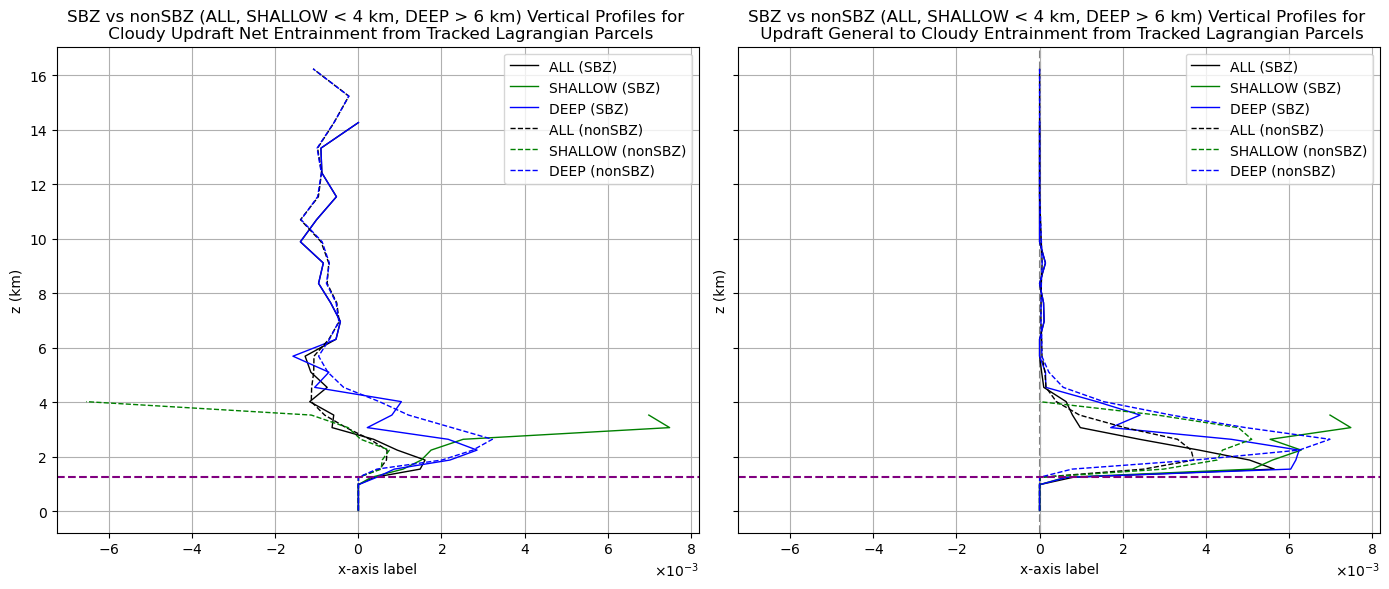

In [75]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True);
PlotOne(axs[0])
PlotTwo(axs[1])
MatchAxisLimits([axs[0],axs[1]],dim='x')

In [206]:
#ColdPool
################################################################

In [207]:
########################
#PLOTTING

In [62]:
type3='general'
type3='cloudy'

type1='ColdPool'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type1}_"+f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
if PROCESSING==False:
    filePath=dir3+f"{data_type1}_"+f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        # print(key)

#this is needed because I wanted to keep consistent with the titles in "profile"
suffix = '_C' if type3 == 'cloudy' else '_G'
for prefix in [type1, type2]:
    for group in ['ALL', 'SHALLOW', 'DEEP']:
        var_name = f"{prefix}_{group}_profile_array_NET{suffix}"
        var_name_target = f"{prefix}_{group}_net"
        globals()[var_name_target] = globals()[var_name]
        print(f"{var_name_target} = {var_name}")

ColdPool_ALL_net = ColdPool_ALL_profile_array_NET_C
ColdPool_SHALLOW_net = ColdPool_SHALLOW_profile_array_NET_C
ColdPool_DEEP_net = ColdPool_DEEP_profile_array_NET_C
nonSBZ_ALL_net = nonSBZ_ALL_profile_array_NET_C
nonSBZ_SHALLOW_net = nonSBZ_SHALLOW_profile_array_NET_C
nonSBZ_DEEP_net = nonSBZ_DEEP_profile_array_NET_C


In [63]:
type1='ColdPool'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type2}_"+f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
if PROCESSING==False:
    filePath=dir3 + f"{data_type2}_" + f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        print(key)

ColdPool_ALL_profile_array_C_TO_G
ColdPool_ALL_profile_array_G_TO_C
ColdPool_DEEP_profile_array_C_TO_G
ColdPool_DEEP_profile_array_G_TO_C
ColdPool_SHALLOW_profile_array_C_TO_G
ColdPool_SHALLOW_profile_array_G_TO_C


In [64]:
#REDUCING FOR CONFERENCE FIGURE
def PlotOne(ax):
    import matplotlib.pyplot as plt
    lw=1
    
    # List of profile arrays and their corresponding labels and x-axis titles
    profiles = [
        (SBZ_ALL_net, SBZ_SHALLOW_net, SBZ_DEEP_net, 'net', 'CL'),
        (ColdPool_ALL_net, ColdPool_SHALLOW_net, ColdPool_DEEP_net, 'net', 'nonCL')
    ]
    
    # Loop through profiles for CL and nonCL
    for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
        # Compute the averaged profile for ALL
        ALL_profile = averaged_profiles(ALL_profile_array)
        SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
        DEEP_profile = averaged_profiles(DEEP_profile_array)
        
        # Plot the profile for ALL (CL and nonCL) on top of each other
        if CLlabel == 'CL':
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='ALL (SBZ)',lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], color='green', label='SHALLOW (SBZ)',lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], color='blue', label='DEEP (SBZ)',lw=lw)
        else:
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='ALL (ColdPool)',lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label='SHALLOW (ColdPool)',lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label='DEEP (ColdPool)',lw=lw)
    
    # Add labels and title
    ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
    ax.set_ylabel('z (km)')
    ax.grid(True)
    
    # ax.set_ylim(0,3)
    
    # Show legend
    ax.legend()
    
    #MEAN CLOUD BASE
    ax.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
    apply_scientific_notation([ax])
    
    # Set up the main title and adjust layout
    ax.set_title(f'SBZ vs ColdPool (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n {type3.title()} Updraft Net Entrainment from Tracked Lagrangian Parcels')
    plt.tight_layout()

    return ax

# #PLOTTING
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111)
# ax1=PlotOne(ax)


In [65]:
#REDUCING FOR CONFERENCE FIGURE
def PlotTwo(ax):
    import matplotlib.pyplot as plt
    lw=1
    
    # List of profile arrays and their corresponding labels and x-axis titles
    profiles = [
        (SBZ_ALL_profile_array_G_TO_C, SBZ_SHALLOW_profile_array_G_TO_C, SBZ_DEEP_profile_array_G_TO_C, 'G_TO_C', 'SBZ'),
        (ColdPool_ALL_profile_array_G_TO_C, ColdPool_SHALLOW_profile_array_G_TO_C, ColdPool_DEEP_profile_array_G_TO_C, 'G_TO_C', 'ColdPool')
    ]
    
    
    cutoff_height=100
    # z_cutoff=7.5
    z_cutoff=np.where(SBZ_ALL_profile_array_G_TO_C[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z
    
    # Loop through profiles for SBZ and ColdPool
    for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, SBZlabel) in enumerate(profiles):
        # Compute the averaged profile for ALL
        ALL_profile = averaged_profiles(ALL_profile_array)
        SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
        DEEP_profile = averaged_profiles(DEEP_profile_array)
    
        #CUT BELOW CERTAIN Z
        ALL_profile=ALL_profile[:z_cutoff]
        SHALLOW_profile=SHALLOW_profile[:z_cutoff]
        DEEP_profile=DEEP_profile[:z_cutoff]
    
        # Plot the profile for ALL (SBZ and ColdPool) on top of each other
        if SBZlabel == 'SBZ':
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='ALL (SBZ)',lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], color='green', label='SHALLOW (SBZ)',lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], color='blue', label='DEEP (SBZ)',lw=lw)
        else:
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='ALL (ColdPool)',lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label='SHALLOW (ColdPool)',lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label='DEEP (ColdPool)',lw=lw)
    
        apply_scientific_notation([ax])
    
    
    
    # ax.set_ylim(0,3)
    
    # Add labels and title
    ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
    ax.set_ylabel('z (km)')
    ax.grid(True)
    
    ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)
    
    # Show legend
    ax.legend()
    
    #MEAN CLOUD BASE
    ax.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
    # Set up the main title and adjust layout
    ax.set_title(f'SBZ vs ColdPool (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n Updraft General to Cloudy Entrainment from Tracked Lagrangian Parcels')
    plt.tight_layout()


# #PLOTTING
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111)
# ax2=PlotTwo(ax)

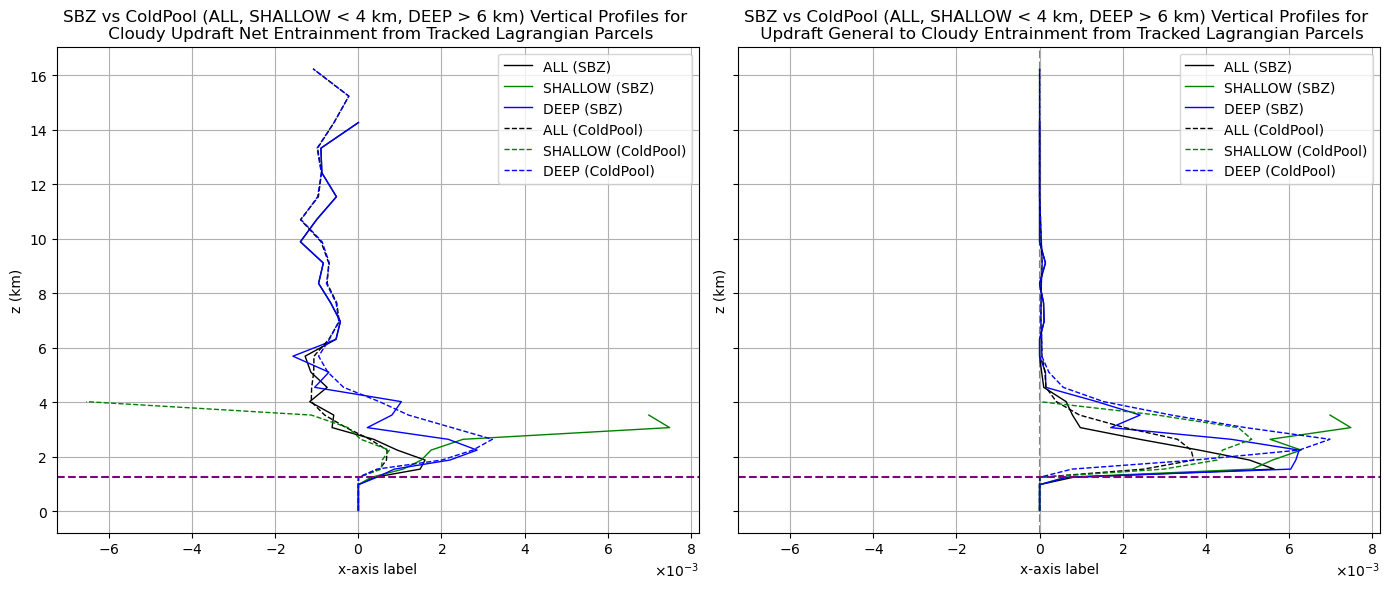

In [66]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True);
PlotOne(axs[0])
PlotTwo(axs[1])
MatchAxisLimits([axs[0],axs[1]],dim='x')